# Semi-Supervised Learning with PyTorch & MNIST

1. **Self-Training:** The model iteratively labels uncertain data itself
2. **Co-Training:** Two models with different "views" train each other
3. **Graph-based Label Propagation:** Labels are propagated via a graph

**Dataset:** MNIST

**Setup:** Only 10% of the data is labeled, 90% is unlabeled

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.semi_supervised import LabelPropagation
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import time
import copy
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## 1. Prepare Dataset

We load MNIST and split it as follows:
- **Labeled:** 600 images (60 per class, ≈ 10%)
- **Unlabeled:** ~5400 images (for SSL training)
- **Validation:** 1000 images
- **Test:** 10,000 images (standard MNIST test split)

In [ ]:
# Transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

full_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Stratified Sampling: 60 images per class
N_LABELED_PER_CLASS = 60
N_CLASSES = 10
N_LABELED = N_LABELED_PER_CLASS * N_CLASSES

all_targets = np.array(full_train.targets)
labeled_indices = []
for cls in range(N_CLASSES):
    cls_idx = np.where(all_targets == cls)[0]
    chosen = np.random.choice(cls_idx, N_LABELED_PER_CLASS, replace=False)
    labeled_indices.extend(chosen.tolist())
labeled_indices = np.array(labeled_indices)

# remaining indicies
all_indices = np.arange(len(full_train))
remaining = np.setdiff1d(all_indices, labeled_indices)

# validation set from the remaining indicies
val_indices = np.random.choice(remaining, 1000, replace=False)
unlabeled_indices = np.setdiff1d(remaining, val_indices)

labeled_dataset = Subset(full_train, labeled_indices)
unlabeled_dataset = Subset(full_train, unlabeled_indices)
val_dataset = Subset(full_train, val_indices)

print(f"Labeled images:    {len(labeled_dataset)}")
print(f"Unlabeled images:  {len(unlabeled_dataset)}")
print(f"Validation images: {len(val_dataset)}")
print(f"Test images:       {len(test_dataset)}")

Labeled images:    600
Unlabeled images:  58400
Validation images: 1000
Test images:       10000


In [ ]:
# DataLoader
BATCH_SIZE = 64
labeled_loader = DataLoader(labeled_dataset, batch_size=BATCH_SIZE, shuffle=True)
unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

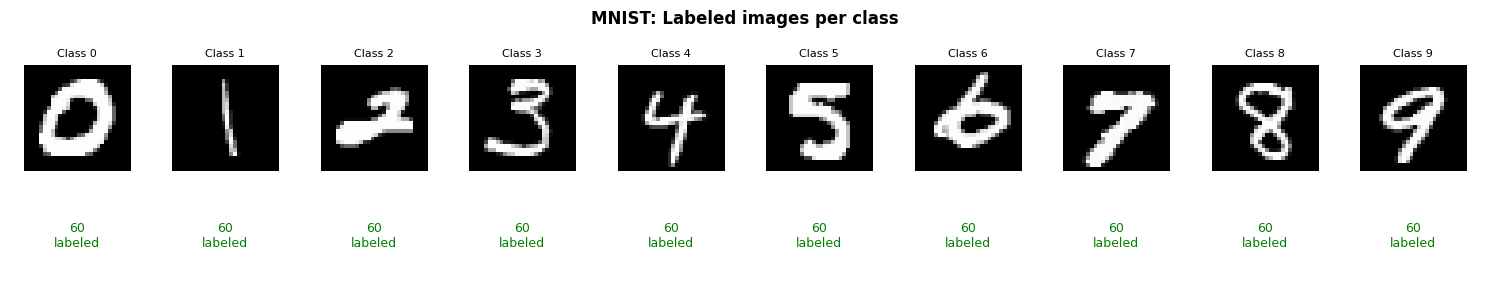

In [ ]:
# Example images
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for cls in range(10):
    for img, label in labeled_dataset:
        if label == cls:
            axes[0, cls].imshow(img.squeeze(), cmap='gray')
            axes[0, cls].set_title(f'Class {cls}', fontsize=8)
            axes[0, cls].axis('off')
            break
    axes[1, cls].text(0.5, 0.5, f'{N_LABELED_PER_CLASS}\nlabeled',
                      ha='center', va='center', fontsize=9, color='green')
    axes[1, cls].axis('off')
plt.suptitle('MNIST: Labeled images per class', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Model Architecture (CNN)


In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, dropout=0.3):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(dropout)

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

    def get_features(self, x):
        """Returns the feature vector for the fully connected layer 2, used for Label Propagation"""
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = F.relu(self.fc1(x))
        return x


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model = SimpleCNN()
print(f"Model parameter: {count_params(model):,}")

Model parameter: 421,642


## 3. Helper Functions

In [ ]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, device):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += images.size(0)
    return total_loss / total, correct / total


def train_model(model, train_loader, val_loader, epochs, lr, device, verbose=True):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_state = None

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        v_loss, v_acc = evaluate(model, val_loader, device)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc)

        if v_acc > best_val_acc:
            best_val_acc = v_acc
            best_state = copy.deepcopy(model.state_dict())

        if verbose and (epoch % 5 == 0 or epoch == 1):
            print(f'  Epoch {epoch:3d}/{epochs} | '
                  f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | '
                  f'Val Loss: {v_loss:.4f} Acc: {v_acc:.4f}')

    model.load_state_dict(best_state)
    return model, history


def plot_history(histories, labels, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

    for i, (hist, lbl) in enumerate(zip(histories, labels)):
        c = colors[i % len(colors)]
        ax1.plot(hist['train_loss'], label=f'{lbl} - Train', color=c, linestyle='-')
        ax1.plot(hist['val_loss'], label=f'{lbl} - Val', color=c, linestyle='--')
        ax2.plot(hist['train_acc'], label=f'{lbl} - Train', color=c, linestyle='-')
        ax2.plot(hist['val_acc'], label=f'{lbl} - Val', color=c, linestyle='--')

    ax1.set_title('Loss function'); ax1.set_xlabel('Epoch'); ax1.legend(fontsize=7)
    ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend(fontsize=7)

    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 4. Baseline: Labeled Data Only

In [ ]:
print("=" * 55)
print("  BASELINE: only labeled images")
print("=" * 55)

t0 = time.time()
baseline_model = SimpleCNN().to(DEVICE)
baseline_model, baseline_history = train_model(
    baseline_model, labeled_loader, val_loader,
    epochs=20, lr=1e-3, device=DEVICE
)
baseline_time = time.time() - t0

_, baseline_test_acc = evaluate(baseline_model, test_loader, DEVICE)
print(f"\nTest accuracy baseline: {baseline_test_acc:.4f} ({baseline_test_acc*100:.2f}%)")
print(f"training time: {baseline_time:.1f}s")

  BASELINE: only labeled images
  Epoch   1/20 | Train Loss: 1.9804 Acc: 0.3467 | Val Loss: 1.3420 Acc: 0.6110
  Epoch   5/20 | Train Loss: 0.3803 Acc: 0.8783 | Val Loss: 0.3339 Acc: 0.8950
  Epoch  10/20 | Train Loss: 0.1332 Acc: 0.9583 | Val Loss: 0.2506 Acc: 0.9210
  Epoch  15/20 | Train Loss: 0.0900 Acc: 0.9717 | Val Loss: 0.2584 Acc: 0.9300
  Epoch  20/20 | Train Loss: 0.0713 Acc: 0.9817 | Val Loss: 0.2472 Acc: 0.9300

Test accuracy baseline: 0.9357 (93.57%)
training time: 8.0s


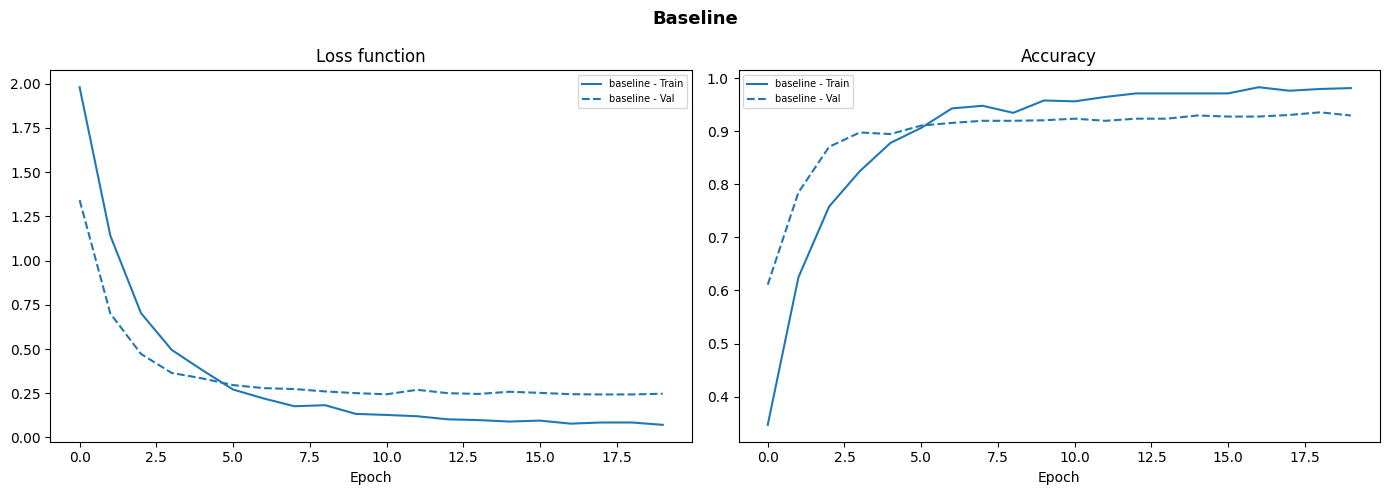

In [ ]:
plot_history([baseline_history], ['baseline'], 'Baseline')

## 5. Self-Training

### How does Self-Training work?

1. **Initial Training:** Train a model with the few labeled data points
2. **Pseudo-Labeling:** Let the model classify the unlabeled data
3. **Confidence Filter:** Select only predictions with high confidence (e.g., > 95%)
4. **Extend Dataset:** Add these "pseudo-labels" to the training dataset
5. **Retrain:** Start training with the extended dataset
6. **Repeat** steps 2–5 for several iterations

**Advantage:** Simple, intuitive

**Risk:** Errors can accumulate ("error propagation")

In [ ]:
def get_pseudo_labels(model, unlabeled_subset, confidence_threshold, device, batch_size=256):
    """
    Classifies unlabeled data.
    Returns the indices and pseudo-labels of all samples whose maximum softmax probability exceeds the threshold.
    """
    loader = DataLoader(unlabeled_subset, batch_size=batch_size, shuffle=False)
    model.eval()
    all_probs, all_preds = [], []
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            logits = model(images)
            probs  = F.softmax(logits, dim=1)
            max_prob, pred = probs.max(1)
            all_probs.append(max_prob.cpu())
            all_preds.append(pred.cpu())
    all_probs = torch.cat(all_probs).numpy()
    all_preds = torch.cat(all_preds).numpy()

    # Only samples above the threshold
    confident_mask = all_probs >= confidence_threshold
    return confident_mask, all_preds, all_probs

# Convert datasets into tensors
def dataset_to_tensors(ds):
    imgs, lbls = [], []
    for img, lbl in DataLoader(ds, batch_size=256, shuffle=False):
        imgs.append(img); lbls.append(lbl)
    return torch.cat(imgs), torch.cat(lbls)

def self_training(labeled_dataset, unlabeled_dataset, val_loader,
                  n_iterations=5, confidence_threshold=0.95,
                  epochs_per_iter=10, lr=1e-3, device=DEVICE):
    print("=" * 17)
    print("  Self-Training")
    print("=" * 17)

    lab_X, lab_y = dataset_to_tensors(labeled_dataset)
    unlab_X, unlab_y = dataset_to_tensors(unlabeled_dataset)

    model = SimpleCNN().to(device)
    current_lab_X = lab_X.clone()
    current_lab_y = lab_y.clone()
    remaining_X = unlab_X.clone()
    remaining_idx = np.arange(len(unlab_X))  # tracking for unlabeled labels

    all_histories = []
    val_accs_per_iter = []
    pseudo_added_per_iter = []
    t_start = time.time()

    for it in range(n_iterations):
        print(f"\n--- Iteration {it+1}/{n_iterations} ---")
        print(f"  Labeled data: {len(current_lab_X)}")
        print(f"  Unlabeled data:  {len(remaining_X)}")

        train_ds = TensorDataset(current_lab_X, current_lab_y)
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)


        model, hist = train_model(model, train_loader, val_loader,
                                  epochs=epochs_per_iter, lr=lr, device=device, verbose=False)
        all_histories.append(hist)

        _, v_acc = evaluate(model, val_loader, device)
        val_accs_per_iter.append(v_acc)
        print(f"  Val-Acc after training: {v_acc:.4f}")

        if len(remaining_X) == 0:
            print("  No unlabeled data remaining.")
            break

        # Pseudo-labels for remaining unlabeled data
        rem_ds = TensorDataset(remaining_X, torch.zeros(len(remaining_X)).long())
        confident_mask, pseudo_labels, probs = get_pseudo_labels(
            model, rem_ds, confidence_threshold, device
        )

        n_confident = confident_mask.sum()
        pseudo_added_per_iter.append(int(n_confident))
        print(f"  Confident Pseudo-Labels (≥{confidence_threshold}): {n_confident}")

        if n_confident == 0:
            print("  No new sample above threshold. Abort.")
            break

        # Add confident samples to labeled dataset
        new_X = remaining_X[confident_mask]
        new_y = torch.tensor(pseudo_labels[confident_mask], dtype=torch.long)
        current_lab_X = torch.cat([current_lab_X, new_X])
        current_lab_y = torch.cat([current_lab_y, new_y])

        # updated remaining unlabled dataset
        remaining_X = remaining_X[~confident_mask]

    total_time = time.time() - t_start
    print(f"\nSelf-Training finished in {total_time:.1f}s")

    return model, all_histories, val_accs_per_iter, pseudo_added_per_iter, total_time

st_model, st_histories, st_val_accs, st_pseudo_added, st_time = self_training(
    labeled_dataset, unlabeled_dataset, val_loader,
    n_iterations=5,
    confidence_threshold=0.95,
    epochs_per_iter=10,
    lr=1e-3,
    device=DEVICE
)

_, st_test_acc = evaluate(st_model, test_loader, DEVICE)
print(f"\n Test accuracy Self-Training: {st_test_acc:.4f} ({st_test_acc*100:.2f}%)")

  Self-Training

--- Iteration 1/5 ---
  Labeled data: 600
  Unlabeled data:  58400
  Val-Acc after training: 0.9220
  Confident Pseudo-Labels (≥0.95): 38598

--- Iteration 2/5 ---
  Labeled data: 39198
  Unlabeled data:  19802
  Val-Acc after training: 0.9500
  Confident Pseudo-Labels (≥0.95): 16222

--- Iteration 3/5 ---
  Labeled data: 55420
  Unlabeled data:  3580
  Val-Acc after training: 0.9590
  Confident Pseudo-Labels (≥0.95): 1620

--- Iteration 4/5 ---
  Labeled data: 57040
  Unlabeled data:  1960
  Val-Acc after training: 0.9650
  Confident Pseudo-Labels (≥0.95): 453

--- Iteration 5/5 ---
  Labeled data: 57493
  Unlabeled data:  1507
  Val-Acc after training: 0.9650
  Confident Pseudo-Labels (≥0.95): 472

Self-Training finished in 123.0s

 Test accuracy Self-Training: 0.9607 (96.07%)


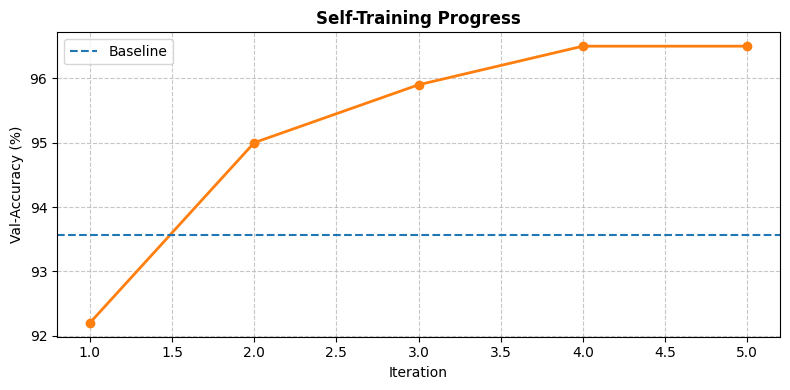

In [ ]:
plt.figure(figsize=(8, 4))

plt.plot(range(1, len(st_val_accs)+1), [a*100 for a in st_val_accs],
         marker='o', color='tab:orange', linewidth=2)
plt.axhline(baseline_test_acc*100, color='tab:blue', linestyle='--', label='Baseline')

plt.title('Self-Training Progress', fontsize=12, fontweight='bold')
plt.xlabel('Iteration')
plt.ylabel('Val-Accuracy (%)')
plt.legend()

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 6. Method 2: Co-Training

### How does Co-Training work?

Co-Training uses **two different models** (or "views") that teach each other:

1. Train two models independently on the labeled data
2. Each model creates pseudo-labels for unlabeled data
3. **Model A** passes its most confident predictions to **Model B** (and vice versa)
4. Both models are retrained with the other's new pseudo-labels
5. Repeat

**Advantage:** More robust than Self-Training due to mutual control
**Requirement:** Two independent views of the data

In [ ]:
class CNNView1(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(64*7*7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64*7*7)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

class CNNView2(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 5, padding=2)
        self.conv2 = nn.Conv2d(16, 32, 5, padding=2)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(0.4)
        self.fc1 = nn.Linear(64*3*3, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 64*3*3)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

In [ ]:
def get_top_k_per_class(model, ds, k_per_class, device):
    """
    Selects the top-k most confident predictions per class for unlabeled data.
    """
    loader = DataLoader(ds, batch_size=256, shuffle=False)
    model.eval()
    all_probs, all_preds = [], []
    with torch.no_grad():
        for imgs, _ in loader:
            logits = model(imgs.to(device))
            probs = F.softmax(logits, dim=1).cpu()
            max_prob, pred = probs.max(1)
            all_probs.append(max_prob)
            all_preds.append(pred)

    all_probs = torch.cat(all_probs).numpy()
    all_preds = torch.cat(all_preds).numpy()

    selected = []
    for cls in range(N_CLASSES):
        cls_idx = np.where(all_preds == cls)[0]
        if len(cls_idx) == 0:
            continue
        # Get indices of top k probabilities for this class
        top_k = cls_idx[np.argsort(all_probs[cls_idx])[-k_per_class:]]
        selected.extend(top_k.tolist())

    return np.array(selected), all_preds

In [ ]:
def co_training(labeled_dataset, unlabeled_dataset, val_loader,
                n_iterations=5, n_per_class=10,
                epochs_per_iter=8, lr=1e-3, device=DEVICE):
    print("=" * 24)
    print("  Method: Co-Training")
    print("=" * 24)

    lab_X, lab_y = dataset_to_tensors(labeled_dataset)
    unlab_X, unlab_y = dataset_to_tensors(unlabeled_dataset)

    # Initialize two models with different architectures
    model_a = CNNView1().to(device)
    model_b = CNNView2().to(device)

    # Separate labeled datasets for mutual teaching
    labX_a, labY_a = lab_X.clone(), lab_y.clone()
    labX_b, labY_b = lab_X.clone(), lab_y.clone()
    remaining_X = unlab_X.clone()

    val_accs_a, val_accs_b = [], []
    added_per_iter = []
    t_start = time.time()

    for it in range(n_iterations):
        print(f"\n--- Iteration {it+1}/{n_iterations} ---")

        # Train Model A
        dl_a = DataLoader(TensorDataset(labX_a, labY_a), batch_size=BATCH_SIZE, shuffle=True)
        model_a, _ = train_model(model_a, dl_a, val_loader, epochs_per_iter, lr, device, verbose=False)

        # Train Model B
        dl_b = DataLoader(TensorDataset(labX_b, labY_b), batch_size=BATCH_SIZE, shuffle=True)
        model_b, _ = train_model(model_b, dl_b, val_loader, epochs_per_iter, lr, device, verbose=False)

        _, va = evaluate(model_a, val_loader, device)
        _, vb = evaluate(model_b, val_loader, device)
        val_accs_a.append(va)
        val_accs_b.append(vb)
        print(f"  Val-Acc A: {va:.4f} | Val-Acc B: {vb:.4f}")

        if len(remaining_X) == 0:
            break

        dummy_ds = TensorDataset(remaining_X, torch.zeros(len(remaining_X)).long())

        # Model A labels for Model B, and Model B labels for Model A
        idx_a, preds_a = get_top_k_per_class(model_a, dummy_ds, n_per_class, device)
        idx_b, preds_b = get_top_k_per_class(model_b, dummy_ds, n_per_class, device)

        # Identify unique indices to remove from unlabeled pool
        all_selected = np.union1d(idx_a, idx_b)
        added_per_iter.append(len(all_selected))
        print(f"  Added A->B: {len(idx_a)} | B->A: {len(idx_b)} | Total unique: {len(all_selected)}")

        # Update labeled sets
        labX_b = torch.cat([labX_b, remaining_X[idx_a]])
        labY_b = torch.cat([labY_b, torch.tensor(preds_a[idx_a], dtype=torch.long)])

        labX_a = torch.cat([labX_a, remaining_X[idx_b]])
        labY_a = torch.cat([labY_a, torch.tensor(preds_b[idx_b], dtype=torch.long)])

        # Update remaining unlabeled data
        mask = np.ones(len(remaining_X), dtype=bool)
        mask[all_selected] = False
        remaining_X = remaining_X[mask]

    total_time = time.time() - t_start
    print(f"\nCo-Training finished in {total_time:.1f}s")
    return model_a, model_b, val_accs_a, val_accs_b, added_per_iter, total_time

# Execute Co-Training
ct_model_a, ct_model_b, ct_val_a, ct_val_b, ct_added, ct_time = co_training(
    labeled_dataset, unlabeled_dataset, val_loader,
    n_iterations=5, n_per_class=15, epochs_per_iter=8, lr=1e-3, device=DEVICE
)

_, ct_test_a = evaluate(ct_model_a, test_loader, DEVICE)
_, ct_test_b = evaluate(ct_model_b, test_loader, DEVICE)
ct_test_acc = max(ct_test_a, ct_test_b)
print(f"\nTest-Acc Model A: {ct_test_a:.4f} | Model B: {ct_test_b:.4f}")
print(f"Best Co-Training Test-Acc: {ct_test_acc*100:.2f}%")

  Method: Co-Training

--- Iteration 1/5 ---
  Val-Acc A: 0.9150 | Val-Acc B: 0.8930
  Added A->B: 150 | B->A: 150 | Total unique: 296

--- Iteration 2/5 ---
  Val-Acc A: 0.9410 | Val-Acc B: 0.9290
  Added A->B: 150 | B->A: 150 | Total unique: 292

--- Iteration 3/5 ---
  Val-Acc A: 0.9460 | Val-Acc B: 0.9310
  Added A->B: 150 | B->A: 150 | Total unique: 293

--- Iteration 4/5 ---
  Val-Acc A: 0.9470 | Val-Acc B: 0.9440
  Added A->B: 150 | B->A: 150 | Total unique: 296

--- Iteration 5/5 ---
  Val-Acc A: 0.9530 | Val-Acc B: 0.9450
  Added A->B: 150 | B->A: 150 | Total unique: 294

Co-Training finished in 35.1s

Test-Acc Model A: 0.9514 | Model B: 0.9506
Best Co-Training Test-Acc: 95.14%


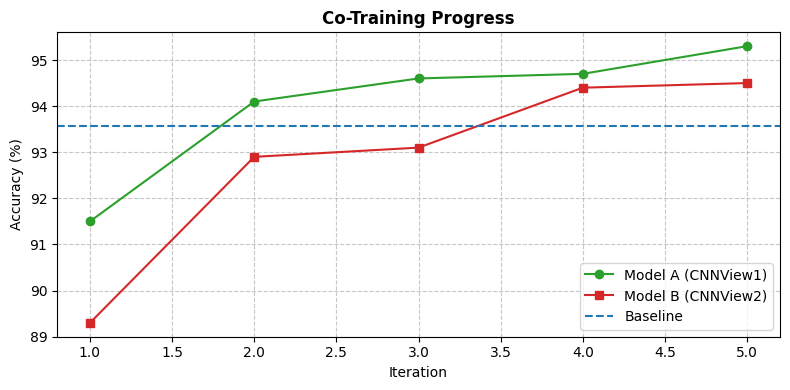

In [ ]:
plt.figure(figsize=(8, 4))

iters = range(1, len(ct_val_a)+1)
plt.plot(iters, [a*100 for a in ct_val_a], marker='o', label='Model A (CNNView1)', color='tab:green')
plt.plot(iters, [a*100 for a in ct_val_b], marker='s', label='Model B (CNNView2)', color='tab:red')
plt.axhline(baseline_test_acc*100, color='tab:blue', linestyle='--', label='Baseline')

plt.title('Co-Training Progress', fontsize=12, fontweight='bold')
plt.xlabel('Iteration')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## 7. Method 3: Graph-based Label Propagation

### How does Label Propagation work?

1. **Build Graph:** Each image is a node. Nodes of similar images are connected (edges = similarity in feature space)
2. **Initialize Labels:** Labeled nodes have known labels. Unlabeled nodes get `-1`
3. **Propagate Labels:** Labels "flow" from labeled to unlabeled nodes along the edges
4. **Iterate:** Repeat until convergence

**Advantage:** Utilizes the global structure of the data

**Requirement:** Needs good features

In [ ]:
def extract_features(model, dataset, device, batch_size=256):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    model.eval()
    features, labels = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            feat = model.get_features(imgs.to(device)).cpu()
            features.append(feat)
            labels.append(lbls)
    return torch.cat(features).numpy(), torch.cat(labels).numpy()

def ds_to_imgs(ds):
    imgs = []
    for img, _ in DataLoader(ds, batch_size=256, shuffle=False):
        imgs.append(img)
    return torch.cat(imgs)

In [ ]:
def graph_label_propagation(baseline_model, labeled_dataset, unlabeled_dataset,
                             val_loader, pca_components=50,
                             final_epochs=20, lr=1e-3, device=DEVICE):
    print("=" * 33)
    print("  Graph-based Label Propagation")
    print("=" * 33)
    t_start = time.time()

    # Extract Features
    print("\nStep 1: Extracting CNN features...")
    feat_lab,   y_lab   = extract_features(baseline_model, labeled_dataset,   device)
    feat_unlab, y_unlab = extract_features(baseline_model, unlabeled_dataset,  device)

    # Combine all features
    all_features = np.vstack([feat_lab, feat_unlab])
    all_true_y = np.concatenate([y_lab, y_unlab])
    n_labeled = len(y_lab)

    # Labels: known for labeled, -1 for unlabeled
    lp_labels = np.full(len(all_features), -1, dtype=int)
    lp_labels[:n_labeled] = y_lab

    print(f"  Features: {all_features.shape[1]}D | Total Samples: {len(all_features)}")

    #  PCA Reduction
    print(f"\nStep 2: PCA → {pca_components} components...")
    scaler = StandardScaler()
    all_features_scaled = scaler.fit_transform(all_features)
    pca = PCA(n_components=pca_components, random_state=42)
    all_features_pca = pca.fit_transform(all_features_scaled)
    print(f"  Explained variance: {pca.explained_variance_ratio_.sum():.3f}")

    #  Label Propagation
    print(f"\nStep 3: Label Propagation (kernel=knn)...")
    lp = LabelPropagation(kernel='knn', n_neighbors=7, max_iter=1000)
    lp.fit(all_features_pca, lp_labels)
    propagated_labels = lp.transduction_

    # Check quality of propagated labels
    unlab_propagated = propagated_labels[n_labeled:]
    unlab_true = all_true_y[n_labeled:]
    lp_accuracy = accuracy_score(unlab_true, unlab_propagated)
    print(f"  Propagation Accuracy on unlabeled data: {lp_accuracy:.4f}")

    # Train CNN with all propagated label
    print(f"\nStep 4: Training CNN with {len(all_features)} samples...")

    lab_imgs = ds_to_imgs(labeled_dataset)
    unlab_imgs = ds_to_imgs(unlabeled_dataset)
    all_imgs = torch.cat([lab_imgs, unlab_imgs])
    all_prop_y = torch.tensor(propagated_labels, dtype=torch.long)

    full_ds = TensorDataset(all_imgs, all_prop_y)
    full_loader = DataLoader(full_ds, batch_size=BATCH_SIZE, shuffle=True)

    model = SimpleCNN().to(device)
    model, history = train_model(model, full_loader, val_loader,
                                 epochs=final_epochs, lr=lr, device=device)

    total_time = time.time() - t_start
    print(f"\nLabel Propagation finished in {total_time:.1f}s")

    return model, history, lp_accuracy, propagated_labels, pca, total_time

lp_model, lp_history, lp_prop_acc, lp_labels_all, lp_pca, lp_time = graph_label_propagation(
    baseline_model, labeled_dataset, unlabeled_dataset, val_loader,
    pca_components=50, final_epochs=20, lr=1e-3, device=DEVICE
)

_, lp_test_acc = evaluate(lp_model, test_loader, DEVICE)
print(f"\n Test Accuracy Label Propagation: {lp_test_acc:.4f} ({lp_test_acc*100:.2f}%)")

  Graph-based Label Propagation

Step 1: Extracting CNN features...
  Features: 128D | Total Samples: 59000

Step 2: PCA → 50 components...
  Explained variance: 0.993

Step 3: Label Propagation (kernel=knn)...
  Propagation Accuracy on unlabeled data: 0.9550

Step 4: Training CNN with 59000 samples...
  Epoch   1/20 | Train Loss: 0.1742 Acc: 0.9427 | Val Loss: 0.1567 Acc: 0.9600
  Epoch   5/20 | Train Loss: 0.0684 Acc: 0.9753 | Val Loss: 0.1901 Acc: 0.9580
  Epoch  10/20 | Train Loss: 0.0358 Acc: 0.9868 | Val Loss: 0.2404 Acc: 0.9580
  Epoch  15/20 | Train Loss: 0.0187 Acc: 0.9933 | Val Loss: 0.3004 Acc: 0.9570
  Epoch  20/20 | Train Loss: 0.0120 Acc: 0.9960 | Val Loss: 0.3344 Acc: 0.9560

Label Propagation finished in 180.4s

 Test Accuracy Label Propagation: 0.9641 (96.41%)


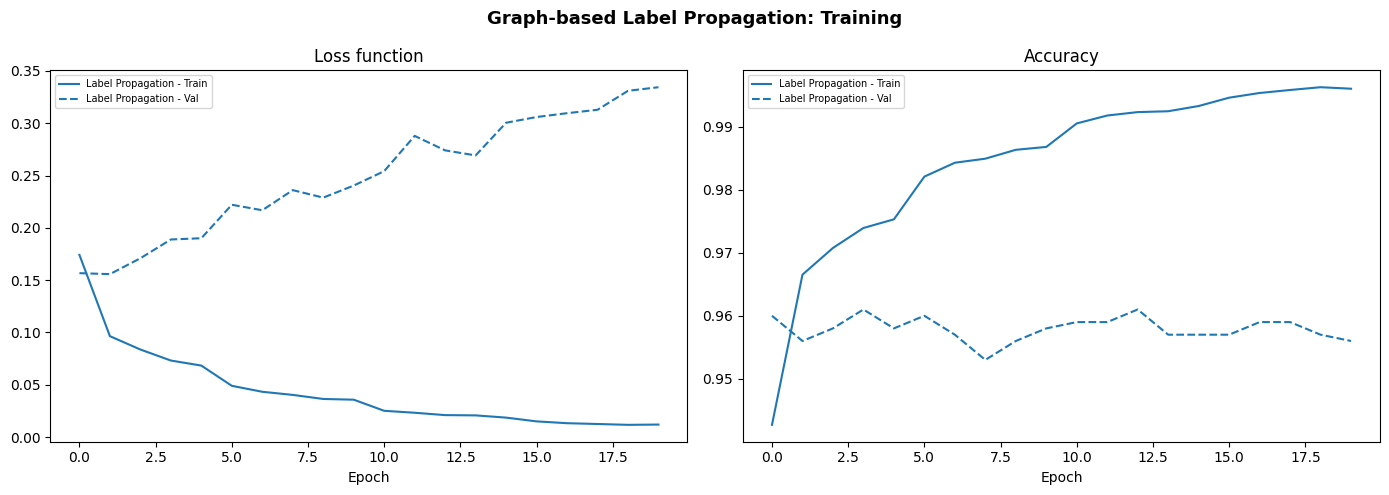

In [ ]:
plot_history([lp_history], ['Label Propagation'], 'Graph-based Label Propagation: Training')

## 8. Evaluation and Comparison of all Methods

In [ ]:
def get_all_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            out = model(imgs.to(device))
            preds = out.argmax(1).cpu()
            all_preds.append(preds)
            all_labels.append(lbls)
    return torch.cat(all_preds).numpy(), torch.cat(all_labels).numpy()

models = {
    'Baseline (labeled only)': baseline_model,
    'Self-Training': st_model,
    'Co-Training (Model A)': ct_model_a,
    'Co-Training (Model B)': ct_model_b,
    'Label Propagation': lp_model,
}

test_accs  = {}
train_times = {
    'Baseline (labeled only)': baseline_time,
    'Self-Training': st_time,
    'Co-Training (Model A)': ct_time / 2,
    'Co-Training (Model B)': ct_time / 2,
    'Label Propagation':  lp_time,
}

print("=" * 50)
print("  Test Accuracy of all methods")
print("=" * 50)
for name, model in models.items():
    _, acc = evaluate(model, test_loader, DEVICE)
    test_accs[name] = acc
    print(f"  {name:<35}: {acc*100:.2f}%")
print("=" * 50)

  Test Accuracy of all methods
  Baseline (labeled only)            : 93.57%
  Self-Training                      : 96.07%
  Co-Training (Model A)              : 95.14%
  Co-Training (Model B)              : 95.06%
  Label Propagation                  : 96.41%


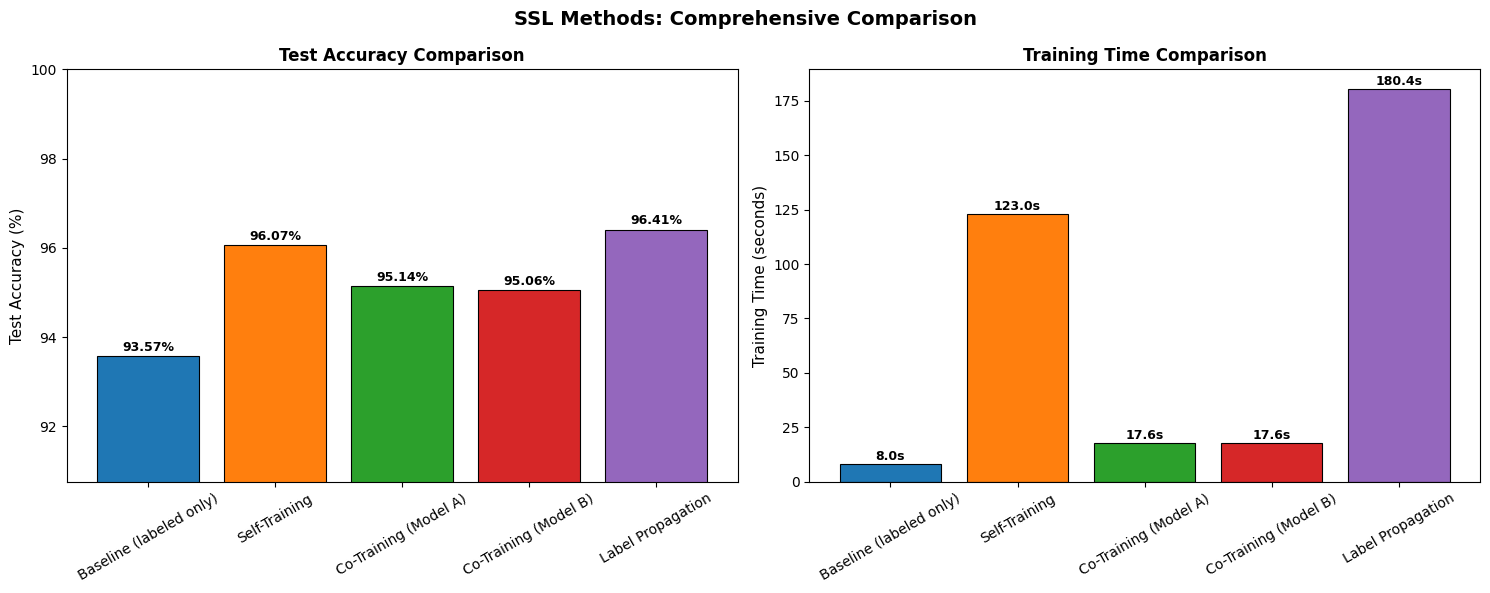

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

names  = list(test_accs.keys())
accs   = [test_accs[n] * 100 for n in names]
times  = [train_times[n] for n in names]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

# Accuracy Bar Chart
bars = axes[0].bar(names, accs, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_ylim(min(accs)*0.97, 100)
axes[0].set_ylabel('Test Accuracy (%)', fontsize=11)
axes[0].set_title('Test Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)

# Training Time Bar Chart
bars2 = axes[1].bar(names, times, color=colors, edgecolor='black', linewidth=0.8)
axes[1].set_ylabel('Training Time (seconds)', fontsize=11)
axes[1].set_title('Training Time Comparison', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
for bar, t in zip(bars2, times):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{t:.1f}s', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.suptitle('SSL Methods: Comprehensive Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "=" * 65)
print("  Comparison report")
print("=" * 65)

baseline_acc = test_accs['Baseline (labeled only)']

results_table = [
    ('Baseline', baseline_acc, baseline_time, '-'),
    ('Self-Training', test_accs['Self-Training'],st_time, f'+{(test_accs["Self-Training"]-baseline_acc)*100:.2f}%'),
    ('Co-Training', ct_test_acc, ct_time, f'+{(ct_test_acc-baseline_acc)*100:.2f}%'),
    ('Label Propagation', lp_test_acc, lp_time, f'+{(lp_test_acc-baseline_acc)*100:.2f}%'),
]

print(f"  {'Method':<25} {'Test-Acc':>10} {'Time (s)':>10} {'Improvement':>14}")
print("  " + "-" * 63)
for name, acc, t, imp in results_table:
    print(f"  {name:<25} {acc*100:>9.2f}% {t:>10.1f} {imp:>14}")
print("=" * 65)


  Comparison report
  Method                      Test-Acc   Time (s)    Improvement
  ---------------------------------------------------------------
  Baseline                      93.57%        8.0              -
  Self-Training                 96.07%      123.0         +2.50%
  Co-Training                   95.14%       35.1         +1.57%
  Label Propagation             96.41%      180.4         +2.84%


## 10. Summary & Reflection

### Findings from the Experiment

---

#### Self-Training
**How it works:** The model iteratively labels new data with high confidence (threshold ≥ 0.95) and thus expands its training dataset.

**Strengths:**
- Very easy to implement and understand
- Only one model needed
- Flexible: Confidence threshold and iterations are easily adjustable

**Weaknesses:**
- **Error Propagation:** Incorrect pseudo-labels are reused in later iterations and can worsen the model
- The vicious cycle starts early at a low initial accuracy level

---

#### Co-Training
**How it works:** Two models with different architectures (different "views" of the data) teach each other with their confident predictions.

**Strengths:**
- **Mutual control** reduces error propagation
- The diversity of views leads to more robust pseudo-labels
- In the end, you have two models that can be ensembled

**Weaknesses:**
- Double computational effort
- Requires genuine differences between views (not just random initialization)
- More complex to implement

---

#### Graph-based Label Propagation
**How it works:** A graph is built from CNN features, where similar images are connected. Labels "flow" from labeled to unlabeled nodes (according to the Manifold Hypothesis: similar points belong to the same class).

**Strengths:**
- Utilizes the **global data structure** – considers more than just local neighbors
- Single propagation, no iterative retraining needed
- Theoretically well-founded (spectral graph theory)

**Weaknesses:**
- Scales poorly: Graph construction is O(n²)
- Sensitive to feature quality
- Requires good initial features (here: CNN features from Baseline)

---

### Conclusion
All three SSL methods improve upon the baseline (labeled data only). The gain from unlabeled data demonstrates the core idea of Semi-Supervised Learning: **The structure of unlabeled data helps the model learn the decision boundary better.**

For MNIST, self-training is often sufficient. For more complex datasets, more robust methods like Co-Training are worthwhile.